In [18]:
from langchain_community.document_loaders import TextLoader
from langchain_huggingface import HuggingFaceEndpointEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import  FAISS
from pydantic import BaseModel
from langchain_core.documents import Document
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,END

In [ ]:
loader=TextLoader("../resourse/sample_docs.txt",encoding="utf-8").load()
chunks=RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50).split_documents(loader)

embeddings=HuggingFaceEndpointEmbeddings(
    repo_id="sentence-transformers/all-MiniLM-L6-v2",
    task="feature-extraction"
)
store=FAISS.from_documents(chunks,embeddings)
retriever=store.as_retriever()
retriever

In [3]:
import os 
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm=ChatGroq(model="llama-3.3-70b-versatile")

In [4]:
class RagStateReflection(BaseModel):
    question:str
    retrieved_data:list[Document]=[]
    answer:str=""
    revisit:bool=False
    reflection:str=""
    attemps:int=0

In [11]:
def retrieve_data(state:RagStateReflection) -> RagStateReflection:
    response=retriever.invoke(state.question)

    return state.model_copy(update={"retrieved_data":response})

def get_answer(state:RagStateReflection) -> RagStateReflection:
    context="/n/n".join(doc.page_content for doc in state.retrieved_data)
    prompt = f"""
Use the following context to answer the question:

Context:
{context}

Question:
{state.question}
"""
    answer=llm.invoke(prompt).content.strip()
    return state.model_copy(update={"answer":answer, "attemps":state.attemps +1})


def reflection(state:RagStateReflection) -> RagStateReflection:
    prompt = f"""
Reflect on the following answer to see if it fully addresses the question. 
State YES if it is complete and correct, or NO with an explanation.

Question: {state.question}

Answer: {state.answer}

Respond like:
Reflection: YES or NO
Explanation: ...
"""
    result=llm.invoke(prompt).content
    is_ok= "reflection: yes" in result.lower()
    return state.model_copy(update={"reflection": state.reflection,"revisit": not is_ok})

def finalize(state:RagStateReflection) -> RagStateReflection:
    return state



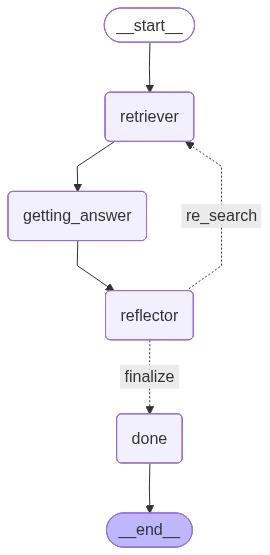

In [17]:
workflow = StateGraph(RagStateReflection)

workflow.add_node("retriever", retrieve_data)
workflow.add_node("getting_answer", get_answer)
workflow.add_node("reflector", reflection)
workflow.add_node("done", finalize)

workflow.set_entry_point("retriever")
workflow.add_edge("retriever", "getting_answer")
workflow.add_edge("getting_answer", "reflector")

workflow.add_conditional_edges(
    "reflector",
    lambda s: "finalize" if not s.revisit or s.attempts >= 2 else "re_search",
    {
        "finalize": "done",
        "re_search": "retriever"
    }
)

workflow.add_edge("done", END)
builder = workflow.compile()
builder


In [16]:
if __name__ == "__main__":
    user_query = "What are the transformer variants in production deployments?"
    init_state = RagStateReflection(question=user_query)
    result = builder.invoke(init_state)

    print("\n🧠 Final Answer:\n", result["answer"])
    print("\n🔁 Reflection Log:\n", result["reflection"])
    print("🔄 Total Attempts:", result["attemps"])


🧠 Final Answer:
 The provided context does not mention transformer variants in production deployments. It discusses the concept of an agent loop, its importance in autonomous systems, and the benefits of agent-based architectures. Therefore, it is not possible to answer the question based on the given context.

🔁 Reflection Log:
 
🔄 Total Attempts: 2
